In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#Ouverture du fichiers 


etranger= pd.read_csv('etranger_nbr.csv',sep=';',encoding='ISO-8859-1')


etranger = etranger.rename(columns = {'ID Bureau':'id_bv'})
etranger = etranger.set_index('id_bv',drop='True')


etranger.head(5)

,nb_etranger,afr_australe,afr_nord,afr_subs,am_cent,ame_nord,ame_sud,asie_cent,asie_est,asie_sud,asie_sud_est,caraïbes,eur_est,eur_ouest,eur_nord,moyen_orient,oceanie
id_bv,,,,,,,,,,,,,,,,,
01_01,180,5,49,26,0,4,9,0,7,5,9,0,17,43,0,6,0
01_02,206,4,55,16,1,12,7,0,15,6,12,3,10,51,4,8,2
01_03,199,2,55,15,0,11,14,4,5,3,12,2,27,39,0,10,0
01_04,237,4,72,33,0,11,14,1,6,4,14,2,19,47,3,7,0
01_05,168,4,42,17,0,12,12,1,6,2,6,1,18,35,2,9,1


In [3]:
#Ouverture du fichier Legislatives 2024 

leg24 = pd.read_csv("res_legislatives_24.csv",sep=";",encoding="ISO-8859-1")


leg24 = leg24.rename(columns = {'ï»¿id_bv':'id_bv'})

leg24 = leg24.set_index('id_bv',drop='True')

leg24.head(5)

,num_circo,nb_procu,nb_inscr,nb_emarg,nb_votant,nb_bl,nb_nul,nb_exprim,NB_ExtGauche,NB_Gauche,NB_Centre,NB_Droite,NB_ExtDroite,NB_Divers
id_bv,,,,,,,,,,,,,,
01_01,1,129,1080,781,781,7,1,773,3,279,324,70,96,1
01_02,1,137,1211,904,904,5,4,895,0,312,414,73,91,5
01_03,1,140,1211,874,874,3,5,866,8,315,346,65,130,2
01_04,1,133,1295,912,912,7,5,900,18,416,315,45,106,0
01_05,1,145,1077,823,823,3,2,818,1,320,356,56,82,3


# 1- Analyse global

## 1-1 Nombre d'étranger dans la liste 

On analyse le nombres de personnes inscrits sur la liste életorale ayant nés à l'étranger 


In [4]:
#Fusion de fichier

inscr_leg = pd.DataFrame(leg24["nb_inscr"])

inscr_leg

etr_leg = etranger.merge(inscr_leg,on='id_bv')

etr_leg.head(5)

,nb_etranger,afr_australe,afr_nord,afr_subs,am_cent,ame_nord,ame_sud,asie_cent,asie_est,asie_sud,asie_sud_est,caraïbes,eur_est,eur_ouest,eur_nord,moyen_orient,oceanie,nb_inscr
id_bv,,,,,,,,,,,,,,,,,,
01_01,180,5,49,26,0,4,9,0,7,5,9,0,17,43,0,6,0,1080
01_02,206,4,55,16,1,12,7,0,15,6,12,3,10,51,4,8,2,1211
01_03,199,2,55,15,0,11,14,4,5,3,12,2,27,39,0,10,0,1211
01_04,237,4,72,33,0,11,14,1,6,4,14,2,19,47,3,7,0,1295
01_05,168,4,42,17,0,12,12,1,6,2,6,1,18,35,2,9,1,1077


In [5]:
#Nombre d'étranger

nb_etranger = np.sum(etranger["nb_etranger"]) 

nb_etranger

254574

In [6]:
p_etr = [np.sum(etr_leg["nb_etranger"]),np.sum(etr_leg["nb_inscr"])-np.sum(etr_leg["nb_etranger"])]

p_etr

[254177, 1110012]

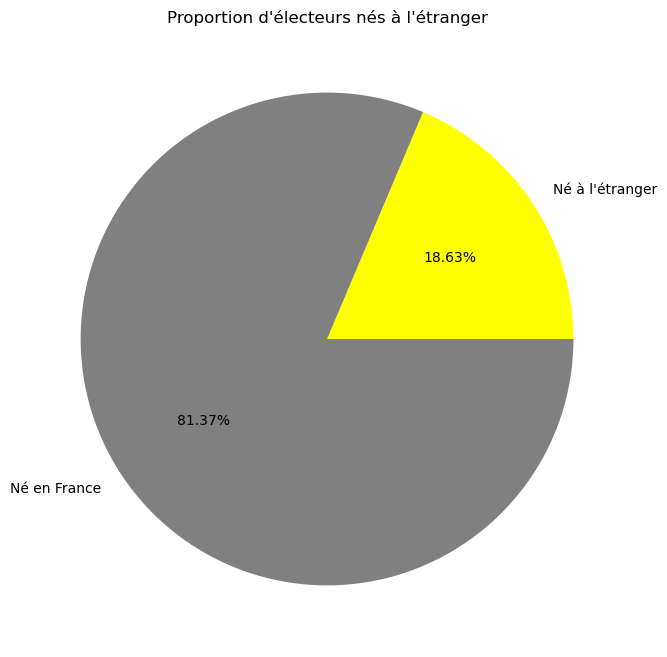

In [7]:
#Diagramme circulaire
plt.figure(figsize=(12,8))


plt.pie(p_etr,labels = ["Né à l'étranger","Né en France"],
        colors = ['yellow','grey'],autopct = '%.2f%%')
plt.title("Proportion d'électeurs nés à l'étranger")

plt.savefig("prop_etr_paris.png")

plt.show()

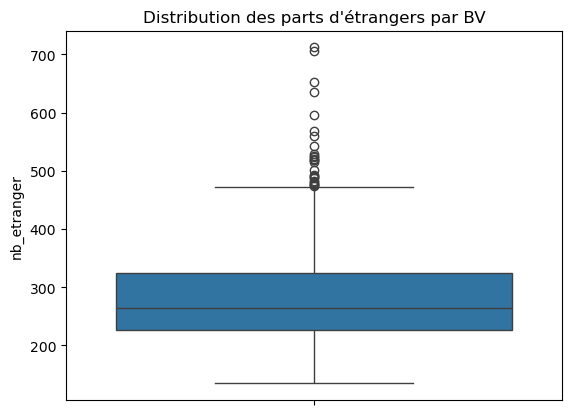

In [8]:
## dsitribution 


#Distribution des écart de voix de gauches 

sns.boxplot(etr_leg["nb_etranger"])

plt.title("Distribution des parts d'étrangers par BV")

plt.savefig("boxplot_etranger.png")

plt.show()

On a une distribution assez inégalitaire en vue que certains bureau de vote sont sureprésenté ( Python reconnait que certain d'entre eux sont des vakeurs abbérentes)

In [9]:
etranger["nb_etranger"].describe()

count    902.000000
mean     282.232816
std       80.858155
min      135.000000
25%      226.250000
50%      265.000000
75%      325.750000
max      712.000000
Name: nb_etranger, dtype: float64

In [10]:
etr_leg["taux_etranger"] = etr_leg["nb_etranger"]/etr_leg["nb_inscr"]

etr_leg["taux_etranger"] = pd.DataFrame(etr_leg["taux_etranger"])

taux_etranger = pd.DataFrame(etr_leg["taux_etranger"])

taux_etranger

,taux_etranger
id_bv,
01_01,0.166667
01_02,0.170107
01_03,0.164327
01_04,0.183012
01_05,0.155989
...,...
20_72,0.205040
20_73,0.170561
20_74,0.168750


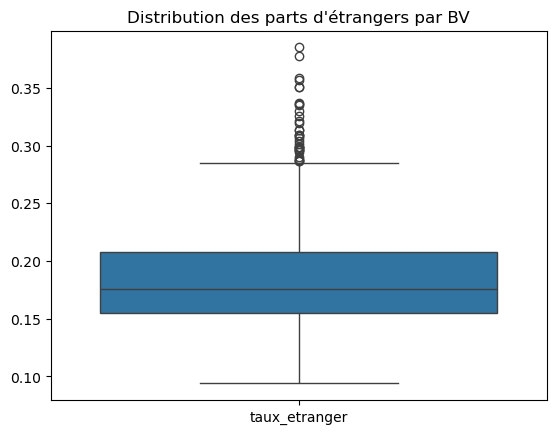

In [11]:
## dsitribution 


#Distribution des écart de voix de gauches 

sns.boxplot(taux_etranger)

plt.title("Distribution des parts d'étrangers par BV")

plt.savefig("boxplot_taux_etranger.png")

plt.show()

In [12]:
type(taux_etranger)

pandas.core.frame.DataFrame

In [13]:
taux_etranger

,taux_etranger
id_bv,
01_01,0.166667
01_02,0.170107
01_03,0.164327
01_04,0.183012
01_05,0.155989
...,...
20_72,0.205040
20_73,0.170561
20_74,0.168750


### 1-2 Analyse par régions du monde 



In [14]:
etr_leg.head(5)

,nb_etranger,afr_australe,afr_nord,afr_subs,am_cent,ame_nord,ame_sud,asie_cent,asie_est,asie_sud,asie_sud_est,caraïbes,eur_est,eur_ouest,eur_nord,moyen_orient,oceanie,nb_inscr,taux_etranger
id_bv,,,,,,,,,,,,,,,,,,,
01_01,180,5,49,26,0,4,9,0,7,5,9,0,17,43,0,6,0,1080,0.166667
01_02,206,4,55,16,1,12,7,0,15,6,12,3,10,51,4,8,2,1211,0.170107
01_03,199,2,55,15,0,11,14,4,5,3,12,2,27,39,0,10,0,1211,0.164327
01_04,237,4,72,33,0,11,14,1,6,4,14,2,19,47,3,7,0,1295,0.183012
01_05,168,4,42,17,0,12,12,1,6,2,6,1,18,35,2,9,1,1077,0.155989


In [15]:
etr_leg.columns

Index(['nb_etranger', 'afr_australe', 'afr_nord', 'afr_subs', 'am_cent',
       'ame_nord', 'ame_sud', 'asie_cent', 'asie_est', 'asie_sud',
       'asie_sud_est', 'caraïbes', 'eur_est', 'eur_ouest', 'eur_nord',
       'moyen_orient', 'oceanie', 'nb_inscr', 'taux_etranger'],
      dtype='object')

In [16]:
#On calcul la sommes des étrangers par partie du monde


etr_region = [np.sum(etr_leg["afr_nord"]),
              np.sum(etr_leg["afr_australe"])+np.sum(etr_leg["afr_subs"]),
              np.sum(etr_leg["ame_nord"]),
              np.sum(etr_leg["am_cent"])+np.sum(etr_leg["caraïbes"]),
              np.sum(etr_leg["ame_sud"]),
              np.sum(etr_leg["moyen_orient"]),
              np.sum(etr_leg["asie_cent"]),
              np.sum(etr_leg["asie_sud"]),
              np.sum(etr_leg["asie_est"])+np.sum(etr_leg["asie_sud_est"]),
              np.sum(etr_leg["eur_est"])+ np.sum(etr_leg["eur_nord"]),
              np.sum(etr_leg["eur_ouest"]),
              np.sum(etr_leg["oceanie"])]
              
etr_region              

[87422, 42698, 9166, 2689, 11809, 15250, 632, 4468, 19814, 21913, 37696, 620]

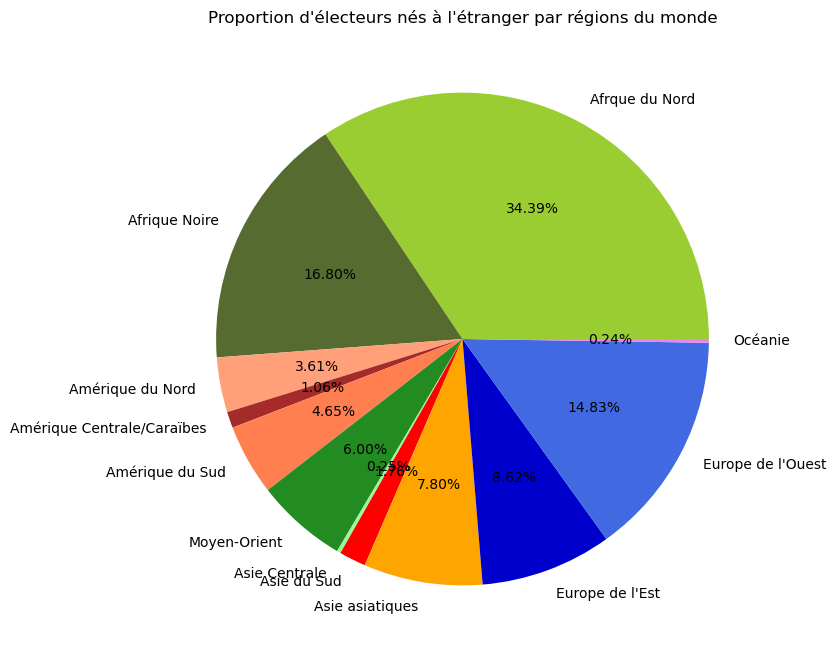

In [17]:

#Diagramme circulaire

plt.figure(figsize=(12,8))


plt.pie(etr_region,labels = ["Afrque du Nord",
                             "Afrique Noire",
                             "Amérique du Nord",
                             "Amérique Centrale/Caraïbes",
                             "Amérique du Sud",
                             "Moyen-Orient",
                             "Asie Centrale",
                             "Asie du Sud",
                             "Asie asiatiques",
                             "Europe de l'Est",
                             "Europe de l'Ouest",
                             "Océanie"],
                             colors = ['yellowgreen',
                                       'darkolivegreen',
                                       'lightsalmon',
                                       'brown',
                                       'coral',
                                       'forestgreen','palegreen','red','orange','mediumblue','royalblue','violet'],autopct = '%.2f%%')
plt.title("Proportion d'électeurs nés à l'étranger par régions du monde")

plt.savefig("prop_etr_paris_reg.png")

plt.show()

### 1-3 Classement des pays 

Le but est d'y établir un classement de pays dont nos électeurs sont d'origine 


In [18]:
#Ouverture des fichier des personnes nés à l'étranger 

liste_etr = pd.read_csv('etrangers_liste.csv',sep=";",encoding="ISO-8859-1")

liste_etr

,code du l'ugle,nom de naissance,nom d'usage,prénoms,sexe,date de naissance,code commune de naissance,libellé commune de naissance,code département de naissance,pays de naissance,...,complément 2,lieu-dit,code postal,commune,pays,code du bureau de vote,libellé du bureau de vote,code circonscription législative du bureau de vote,id bureau de vote,libellé circonscription métropolitaine du bureau de vote
0,com75111,A NAR,NaN,Marie,F,22/03/1960,NaN,KONTUM,99,VIÊT NAM,...,NaN,121903.0,75011.0,PARIS,France,26.0,ECOLE MATERNELLE,75-07,11_26,NaN
1,com75119,A PIOU,NaN,Nathalie Michèle Isabelle,F,22/10/1973,NaN,N DJAMENA,99,TCHAD,...,NaN,44903.0,75019.0,PARIS,France,11.0,ECOLE ELEMENTAIRE,75-16,19_11,NaN
2,com75108,AABBOUBI,NaN,Loubna,F,24/06/1980,NaN,CASABLANCA,99,MAROC,...,NaN,54019.0,75008.0,PARIS 8E ARRONDISSEMENT,NaN,18.0,ECOLE ELEMENTAIRE,75-01,08_18,NaN
3,com75114,AABIBOU,NaN,Hamid,M,01/04/1961,NaN,MEKNES,99,MAROC,...,NaN,158917.0,75014.0,PARIS 14E ARRONDISSEMENT,NaN,17.0,ECOLE ELEMENTAIRE,75-11,14_17,NaN
4,com75114,AABID,NaN,Fatima,F,18/08/1980,NaN,AMEUR,99,MAROC,...,NaN,32586.0,75014.0,PARIS 14E ARRONDISSEMENT,NaN,51.0,ECOLE MATERNELLE,75-10,14_51,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255587,com75114,ZYMONYI,NaN,Luca Villo,F,01/05/1998,NaN,BUDAPEST,99,HONGRIE,...,NaN,NaN,75014.0,PARIS 14E ARRONDISSEMENT,NaN,41.0,ECOLE POLYVALENTE,75-10,14_41,NaN
255588,com75113,ZYRYANOV,NaN,Denis,M,27/02/1973,NaN,MOSCOU,99,U.R.S.S.,...,NaN,110650.0,75013.0,PARIS 13E ARRONDISSEMENT,NaN,39.0,LYCEE PROFESSIONNEL GASTON BACHELARD,75-10,13_39,NaN
255589,com75119,ZYSKOWSKI,NaN,Robert Clément,M,24/05/1988,NaN,SEATTLE,99,ÉTATS-UNIS,...,NaN,43627.0,75019.0,PARIS 19E ARRONDISSEMENT,NaN,4.0,LYCEE PROFESSIONNEL ARMAND CARREL,75-16,19_04,NaN
255590,com75109,ZYSSET,MOREL,Frédérique,F,05/09/1953,NaN,DIMBOKRO,99,CÔTE D'IVOIRE,...,NaN,52887.0,75009.0,PARIS,France,4.0,ECOLE MATERNELLE,75-01,09_04,NaN


In [19]:
liste_etr.shape

(255592, 25)

In [20]:
liste_etr.columns

Index(['code du l'ugle', 'nom de naissance', 'nom d'usage', 'prénoms', 'sexe',
       'date de naissance', 'code commune de naissance',
       'libellé commune de naissance', 'code département de naissance',
       'pays de naissance', 'parti_monde', 'libellé nationalité',
       'numéro de voie', 'libellé de voie', 'complément 1', 'complément 2',
       'lieu-dit', 'code postal', 'commune', 'pays', 'code du bureau de vote',
       'libellé du bureau de vote',
       'code circonscription législative du bureau de vote',
       'id bureau de vote',
       'libellé circonscription métropolitaine du bureau de vote'],
      dtype='object')

In [21]:
count_pays = pd.DataFrame(liste_etr['pays de naissance'].value_counts())

count_pays_15 = count_pays.head(15)

count_pays_15

,count
pays de naissance,
ALGÉRIE,33458
MAROC,30378
TUNISIE,21208
ITALIE,7867
SÉNÉGAL,7190
LIBAN,6664
ALLEMAGNE,6575
CÔTE D'IVOIRE,6436
PORTUGAL,6044


In [22]:
#Suppresion de la colonnne index

count_pays_15 = count_pays_15.reset_index()


<BarContainer object of 15 artists>

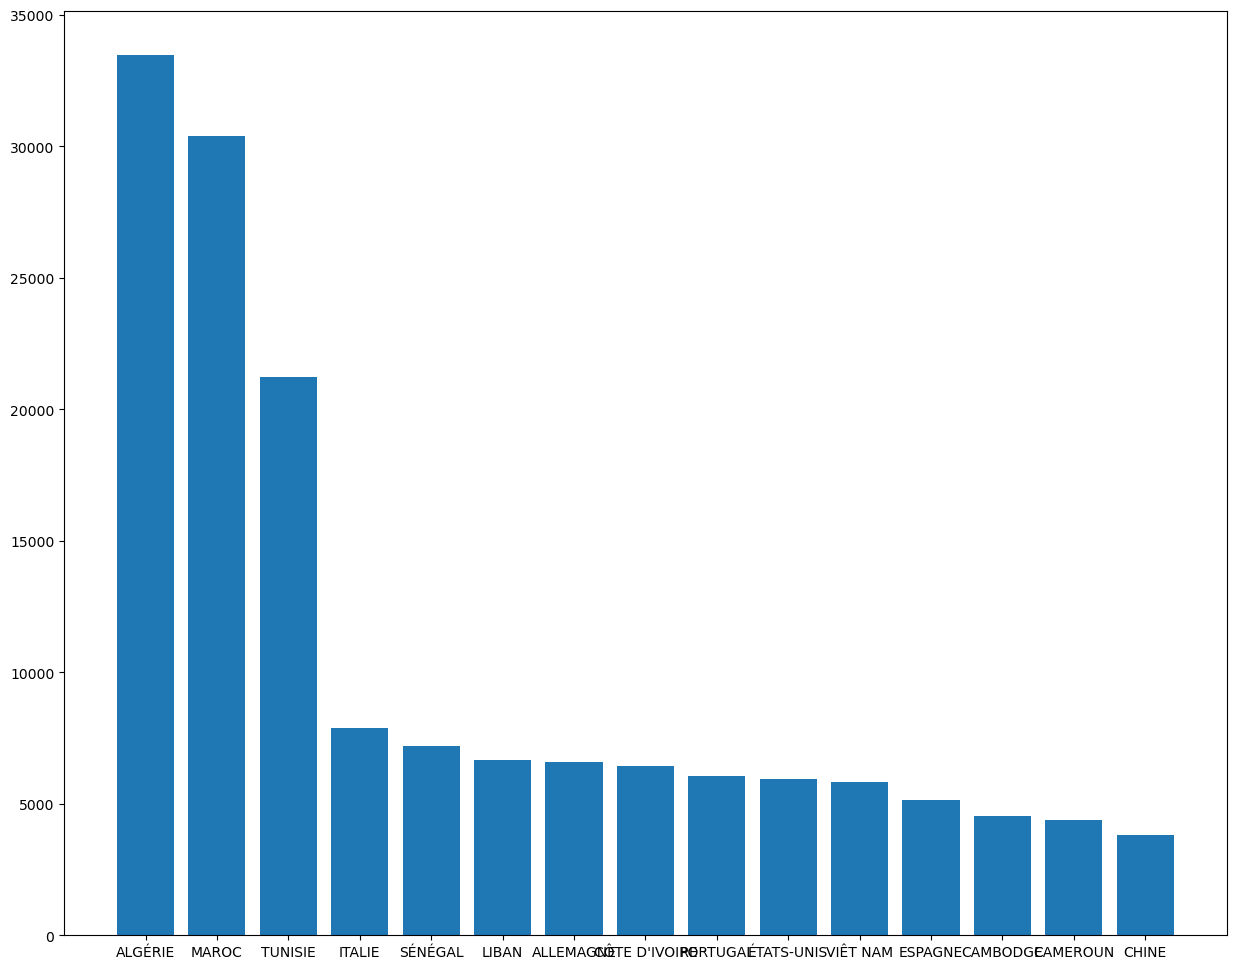

In [23]:
plt.figure(figsize=(15,12))

plt.bar(count_pays_15["pays de naissance"],count_pays_15["count"])

On a une forte préence des pays du Maghreb d'où forme les 3 premiers dans le classement

# 2 - Electeurs étranger en foncions des tendances politiques 

### 2-1 Electeures de gauche


Analyser les résultats des legisltives en foncion des proportions d'étranger dans les bureux de vote parisien 

In [24]:
#Ouverture des données legislatives 

gauche = pd.read_csv('res_gauche.csv',sep=";",encoding ="ISO-8859-1")

gauche = gauche.rename(columns = {'ï»¿id_bv':'id_bv'})

gauche = gauche.set_index('id_bv',drop='True')

gauche.head(5)

,total_G_EUR,total_G_LEG,ecart_voix_G,p_G_EUR,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,ExtGauche,partie_dominant
id_bv,,,,,,,,,,,,
01_01,295,282,-13,"0,4617","0,3648",136,66,4,84,3,2,Partie Socialiste
01_02,329,312,-17,"0,4796","0,3486",171,72,5,71,9,1,Partie Socialiste
01_03,369,323,-46,"0,4933","0,3730",178,86,11,86,5,3,Partie Socialiste
01_04,390,434,44,"0,5328","0,4822",175,66,15,125,5,4,Partie Socialiste
01_05,338,321,-17,"0,5248","0,3924",173,79,5,75,5,1,Partie Socialiste


In [25]:
partie_gauche = pd.DataFrame(gauche["partie_dominant"]) 

partie_gauche.head(10)

,partie_dominant
id_bv,
01_01,Partie Socialiste
01_02,Partie Socialiste
01_03,Partie Socialiste
01_04,Partie Socialiste
01_05,Partie Socialiste
01_06,Partie Socialiste
01_07,Partie Socialiste
01_08,Partie Socialiste
01_09,Partie Socialiste


In [26]:
#Taux d'étranger 

taux_etranger = pd.DataFrame(etr_leg["taux_etranger"])

taux_etranger.head(5)

,taux_etranger
id_bv,
01_01,0.166667
01_02,0.170107
01_03,0.164327
01_04,0.183012
01_05,0.155989


In [27]:
gauche_etr = taux_etranger.merge(partie_gauche,on='id_bv')

gauche_etr

,taux_etranger,partie_dominant
id_bv,,
01_01,0.166667,Partie Socialiste
01_02,0.170107,Partie Socialiste
01_03,0.164327,Partie Socialiste
01_04,0.183012,Partie Socialiste
01_05,0.155989,Partie Socialiste
...,...,...
20_72,0.205040,La France Insoumise
20_73,0.170561,La France Insoumise
20_74,0.168750,La France Insoumise


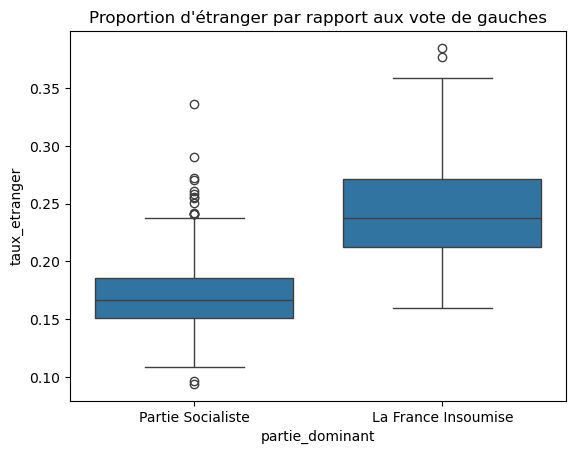

In [28]:
#Boite à moustache 

sns.boxplot(gauche_etr, x="partie_dominant", y="taux_etranger")

plt.title("Proportion d'étranger par rapport aux vote de gauches")

plt.savefig('box_G_etr.png')

plt.show()

In [47]:
etr_leg.head(2)

,nb_etranger,afr_australe,afr_nord,afr_subs,am_cent,ame_nord,ame_sud,asie_cent,asie_est,asie_sud,asie_sud_est,caraïbes,eur_est,eur_ouest,eur_nord,moyen_orient,oceanie,nb_inscr,taux_etranger
id_bv,,,,,,,,,,,,,,,,,,,
01_01,180,5,49,26,0,4,9,0,7,5,9,0,17,43,0,6,0,1080,0.166667
01_02,206,4,55,16,1,12,7,0,15,6,12,3,10,51,4,8,2,1211,0.170107


In [49]:
etr_leg["p_afriqueNord"] = etr_leg["afr_nord"]/etr_leg["nb_etranger"]

In [ ]:


# Création de nouvelle variables

'''
etr_leg["p_afriqueNord"] = etr_leg["afr_nord"]/etr["nb_etranger"]
#etr_leg["p_afriqueNoire"]) = [etr_leg["afr_subs"]),
              np.sum(etr_leg["ame_nord"]),
              np.sum(etr_leg["am_cent"])+np.sum(etr_leg["caraïbes"]),
              np.sum(etr_leg["ame_sud"]),
              np.sum(etr_leg["moyen_orient"]),
              np.sum(etr_leg["asie_cent"]),
              np.sum(etr_leg["asie_sud"]),
              np.sum(etr_leg["asie_est"])+np.sum(etr_leg["asie_sud_est"]),
              np.sum(etr_leg["eur_est"])+ np.sum(etr_leg["eur_nord"]),
              np.sum(etr_leg["eur_ouest"]),
              np.sum(etr_leg["oceanie"])]
              
etr_region

'''



### 2-2 Electeurs de droites

On va analyser le taux d'étranger en fonction des votes de droites dans le bureau de vote 

In [29]:
#Ouverture des données legislatives 

droite = pd.read_csv('res_droite.csv',sep=";",encoding ="ISO-8859-1")

droite = droite.rename(columns = {'ï»¿id_bv':'id_bv'})

droite = droite.set_index('id_bv',drop='True')

droite.head(5)

,v_D_EUR,p_D_EUR,v_D_LEG,p_D_LEG,ecart_D,nb_LR,nb_RN,nb_Rec,nb_autreDroite,nb_extDroite,partie_dominant
id_bv,,,,,,,,,,,
01_01,188,"0,2942",166,"0,2147",-22,72,60,42,2,12,Les RÃ©publicains
01_02,154,"0,2245",164,"0,1832",10,54,54,37,2,7,Les RÃ©publicains
01_03,183,"0,2447",195,"0,2252",12,58,71,37,0,17,Rassemblement National
01_04,175,"0,2391",151,"0,1678",-24,51,69,34,1,20,Rassemblement National
01_05,153,"0,2376",138,"0,1687",-15,44,53,41,3,12,Rassemblement National


In [30]:
#Partie de droite

partie_droite = pd.DataFrame(droite["partie_dominant"]) 

partie_droite.head(10)

,partie_dominant
id_bv,
01_01,Les RÃ©publicains
01_02,Les RÃ©publicains
01_03,Rassemblement National
01_04,Rassemblement National
01_05,Rassemblement National
01_06,Les RÃ©publicains
01_07,Les RÃ©publicains
01_08,Les RÃ©publicains
01_09,Les RÃ©publicains


In [31]:
droite_etr = taux_etranger.merge(partie_droite,on='id_bv')

droite_etr

,taux_etranger,partie_dominant
id_bv,,
01_01,0.166667,Les RÃ©publicains
01_02,0.170107,Les RÃ©publicains
01_03,0.164327,Rassemblement National
01_04,0.183012,Rassemblement National
01_05,0.155989,Rassemblement National
...,...,...
20_72,0.205040,Rassemblement National
20_73,0.170561,Rassemblement National
20_74,0.168750,Rassemblement National


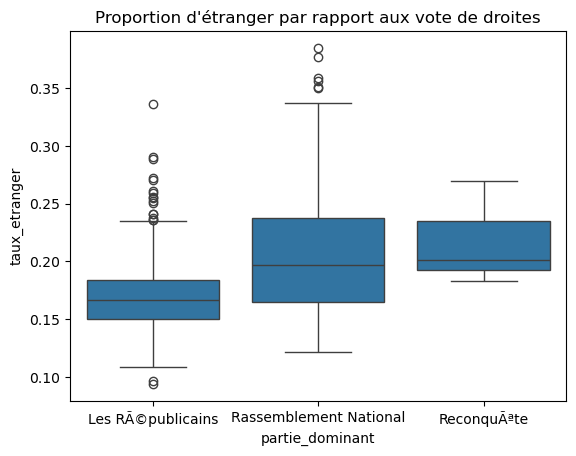

In [32]:
#Boite à moustache 

sns.boxplot(droite_etr, x="partie_dominant", y="taux_etranger")

plt.title("Proportion d'étranger par rapport aux vote de droites")

plt.savefig('box_D_etr.png')

plt.show()

On remarque que le Rassement National est plus élévé dans les taux d'étranger plus élévés 